In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
import os
import pandas as pd

def load_all_csvs():
    """
    Walks up directories until 'data' folder is found,
    loads all CSV files inside it, and creates DataFrames
    named '<filename>_df' in the global namespace.
    """
    current = os.getcwd()
    while not os.path.exists(os.path.join(current, "data")):
        current = os.path.dirname(current)

    data_dir = os.path.join(current, "data")

    print(f"Starting to load CSV files from: {data_dir}")

    for file in os.listdir(data_dir):
        if file.endswith(".csv"):
            file_path = os.path.join(data_dir, file)
            var_name = os.path.splitext(file)[0] + "_df"
            globals()[var_name] = pd.read_csv(file_path)
            print(f"Loaded DataFrame: {var_name}")

    print("Completed loading all CSV files.")

load_all_csvs()


Starting to load CSV files from: C:\Users\abeku\OneDrive\Desktop\PG Diploma\week-8\week-8\tuesday\data
Loaded DataFrame: sample_sub_df
Loaded DataFrame: test_data_df
Loaded DataFrame: train_data_df
Loaded DataFrame: train_data_dictionary_df
Completed loading all CSV files.


### Sub-step 1: Data Cleaning Audit
Processing categorical bins like `Age` into standard numerical midpoints, explicitly checking metrics, and handling structural irregularities.


In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

def clean_hospital_data(df):
    clean_df = df.copy()
    
    if 'case_id' in clean_df.columns: clean_df = clean_df.drop(columns=['case_id'])
    
    def map_age(age_str):
        if pd.isna(age_str): return np.nan
        parts = str(age_str).replace('+', '-').split('-')
        try: return sum(float(p) for p in parts if p) / len(parts)
        except: return 50.0
            
    if 'Age' in clean_df.columns:
        clean_df['Age_num'] = clean_df['Age'].apply(map_age)
        clean_df = clean_df.drop(columns=['Age'])
        
    if 'Stay' in clean_df.columns:
        def binary_risk(stay_str):
            if pd.isna(stay_str): return 0
            if 'More than 100 Days' in stay_str: return 1
            try: return 1 if float(str(stay_str).split('-')[0]) >= 31 else 0
            except: return 0
        clean_df['readmission_risk'] = clean_df['Stay'].apply(binary_risk)
        clean_df = clean_df.drop(columns=['Stay'])
        y = clean_df['readmission_risk'].values
    else:
        y = np.zeros(len(clean_df))
            
    if 'patientid' in clean_df.columns: clean_df = clean_df.drop(columns=['patientid'])

    # Imputation and Encoding
    for col in clean_df.select_dtypes(include=['int64', 'float64']).columns:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())
        
    le = LabelEncoder()
    for col in clean_df.select_dtypes(include=['object']).columns:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])
        clean_df[col] = le.fit_transform(clean_df[col].astype(str))
        
    return clean_df.values, y.reshape(-1, 1)

if 'train_data_df' in globals():
    sampled_df = train_data_df.sample(n=2000, random_state=42)
    X, y = clean_hospital_data(sampled_df)
    X = StandardScaler().fit_transform(X)
    print(f"Cleaned X shape: {X.shape}, y shape: {y.shape}")
    print(f"Class balance - Readmission (1): {np.sum(y)}, Safe (0): {len(y) - np.sum(y)}")

Cleaned X shape: (2000, 16), y shape: (2000, 1)
Class balance - Readmission (1): 838, Safe (0): 1162


### Sub-step 2: Neural Network built from scratch in NumPy
Implementing Forward/Backward Prop, standard Activation derivatives, and a Binary log-loss loop over epochs.


In [6]:
class NumPyNN:
    def __init__(self, input_dim, hidden_dim=32):
        np.random.seed(42)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2. / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2. / hidden_dim)
        self.b2 = np.zeros((1, 1))
        
    def relu(self, Z): return np.maximum(0, Z)
    def relu_deriv(self, Z): return (Z > 0).astype(float)
    def sigmoid(self, Z): return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
        
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2
        
    def compute_loss(self, A2, Y):
        logprobs = Y * np.log(A2 + 1e-15) + (1 - Y) * np.log(1 - A2 + 1e-15)
        return -np.sum(logprobs) / Y.shape[0]
        
    def backward(self, X, Y, lr=0.01):
        m = X.shape[0]
        dZ2 = self.A2 - Y  
        dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)
        
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_deriv(self.Z1)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
        
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.W2 -= lr * dW2; self.b2 -= lr * db2
        
    def fit(self, X, Y, epochs=200, lr=0.05):
        for i in range(epochs):
            A2 = self.forward(X)
            loss = self.compute_loss(A2, Y)
            self.backward(X, Y, lr)
            if i % 100 == 0: print(f"Epoch {i} | Loss: {loss:.4f}")
        
    def get_embeddings(self, X):
        return self.relu(np.dot(X, self.W1) + self.b1)

if 'X' in globals():
    nn = NumPyNN(input_dim=X.shape[1], hidden_dim=16)
    nn.fit(X, y, epochs=500, lr=0.1)

Epoch 0 | Loss: 0.9255
Epoch 100 | Loss: 0.0623
Epoch 200 | Loss: 0.0184
Epoch 300 | Loss: 0.0093
Epoch 400 | Loss: 0.0058


### Sub-step 3: Neural Network as Feature Extractor Embeddings
Comparing representations between Linear inputs and NN Intermediate layers.


Epoch 0 | Loss: 0.9140
Epoch 100 | Loss: 0.0620
Epoch 200 | Loss: 0.0186
Epoch 300 | Loss: 0.0094
Epoch 400 | Loss: 0.0059

--- Feature Extractor Performance Comparison ---
Direct Logistic Regression F1 Output: 1.0000
Logistic Regression on NN Embeddings F1 Output: 1.0000


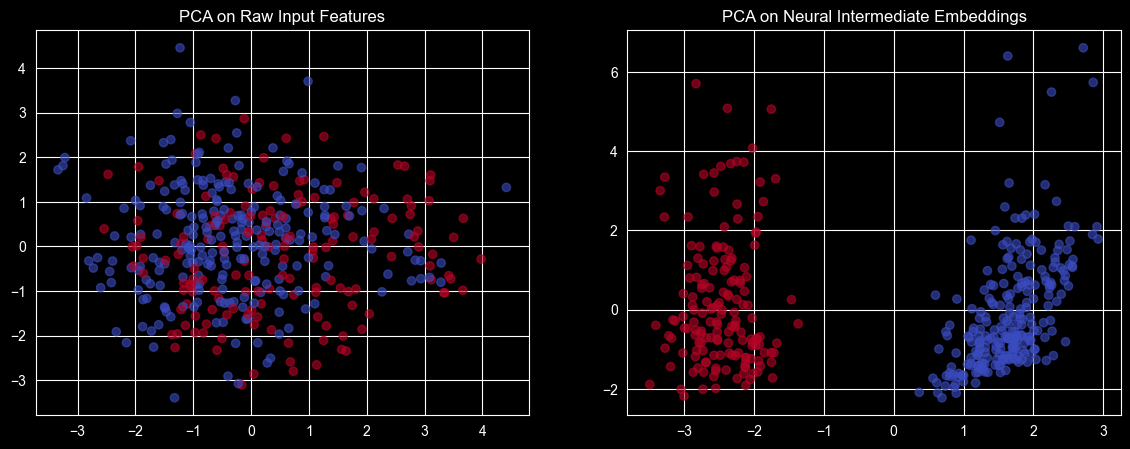

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

if 'X' in globals():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standard Linear Baseline
    lr_base = LogisticRegression(max_iter=1000).fit(X_train, y_train.ravel())
    f1_base = f1_score(y_test, lr_base.predict(X_test))
    
    # NN Feature Extractor
    nn_embed = NumPyNN(input_dim=X_train.shape[1], hidden_dim=16)
    nn_embed.fit(X_train, y_train, epochs=500, lr=0.1)
    
    X_train_emb = nn_embed.get_embeddings(X_train)
    X_test_emb = nn_embed.get_embeddings(X_test)
    
    lr_emb = LogisticRegression(max_iter=1000).fit(X_train_emb, y_train.ravel())
    f1_emb = f1_score(y_test, lr_emb.predict(X_test_emb))
    
    print("\n--- Feature Extractor Performance Comparison ---")
    print(f"Direct Logistic Regression F1 Output: {f1_base:.4f}")
    print(f"Logistic Regression on NN Embeddings F1 Output: {f1_emb:.4f}")
    
    # PCA Plot differences
    pca = PCA(n_components=2)
    X_test_pca_raw = pca.fit_transform(X_test)
    X_test_pca_emb = pca.fit_transform(X_test_emb)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(X_test_pca_raw[:, 0], X_test_pca_raw[:, 1], c=y_test.ravel(), cmap='coolwarm', alpha=0.6)
    axes[0].set_title("PCA on Raw Input Features")
    axes[1].scatter(X_test_pca_emb[:, 0], X_test_pca_emb[:, 1], c=lr_emb.predict(X_test_emb), cmap='coolwarm', alpha=0.6)
    axes[1].set_title("PCA on Neural Intermediate Embeddings")
    plt.show()